# Lib

In [1]:
!pip install -q easyocr ultralytics cvzone

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.4 MB/s eta 0:00:00a 0:00:01


# Running OCR on video

In [3]:
import numpy as np
import cv2
import os
from ultralytics import YOLO
import cvzone
import easyocr


# ── Config ────────────────────────────────────────────────────────────────────
VIDEO_PATH      = r"/kaggle/input/datasets/ahmedhossamelrayes/ocr-trying/nr.mp4"
MODEL_PATH      = r"/kaggle/input/models/ahmedhossamelrayes/ocr/pytorch/v4/1/license-plate-ocr-v4.pt"
CONF_THRESHOLD  = 0.1       # YOLO detection confidence
OCR_CONF_MIN    = 0.1       # Minimum PaddleOCR confidence to accept text
TARGET_WIDTH    = 1020      # Resize frame to this width (height auto-scales)
IMGSZ           = 640       # Must match your training imgsz
OCR_EVERY_N     = 5         # Run OCR once every N frames (performance)
LANG            = 'en'      # 'en' for English plates, 'ar' for Arabic
PLATE_CLASS     = "License_Plate"   # ← Only this class triggers OCR
# ─────────────────────────────────────────────────────────────────────────────

# 1. Load YOLO model
model = YOLO(MODEL_PATH)
class_names = model.names

# 2. Initialize EasyOCR
reader = easyocr.Reader([LANG], gpu=True)

# 3. Open video with existence check
if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: '{VIDEO_PATH}'")

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise IOError(f"Could not open video: '{VIDEO_PATH}'")

# Get video properties for the writer
fps = cap.get(cv2.CAP_PROP_FPS)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = None  # Will be initialized after first frame resize


def preprocess_for_ocr(crop: np.ndarray) -> np.ndarray:
    """
    Improve OCR accuracy by:
      - Converting to grayscale (reduces color noise)
      - Upscaling small crops (PaddleOCR struggles below ~80px height)
      - Applying CLAHE (contrast normalization for dark/washed-out plates)
      - Sharpening (recovers edges lost during detection crop)
    """
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # Upscale if the crop is too small
    h, w = gray.shape
    if h < 80:
        scale = 80 / h
        gray = cv2.resize(gray, (int(w * scale), 80), interpolation=cv2.INTER_CUBIC)

    # CLAHE — improves contrast on dim or overexposed plates
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    gray = clahe.apply(gray)

    # Sharpening kernel
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(gray, -1, kernel)

    # PaddleOCR accepts BGR, so convert back
    return cv2.cvtColor(sharpened, cv2.COLOR_GRAY2BGR)


def perform_ocr(image_array: np.ndarray) -> str:
    if image_array is None or image_array.size == 0:
        return ""

    results = reader.readtext(image_array)

    filtered = [
        text
        for (_, text, conf) in results
        if conf >= OCR_CONF_MIN
    ]
    return " ".join(filtered).strip()


def clamp_box(x1, y1, x2, y2, frame_h, frame_w):
    """Clamp box coordinates to stay within frame boundaries."""
    return (
        max(0, x1), max(0, y1),
        min(frame_w, x2), min(frame_h, y2)
    )


# OCR cache: stores last known text per detection position
# Key: rough grid cell (avoids re-running OCR on the same stationary plate)
ocr_cache: dict[tuple, str] = {}
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Resize preserving aspect ratio
    orig_h, orig_w = frame.shape[:2]
    scale_ratio = TARGET_WIDTH / orig_w
    new_h = int(orig_h * scale_ratio)
    frame = cv2.resize(frame, (TARGET_WIDTH, new_h))
    frame_h, frame_w = frame.shape[:2]

    # YOLO inference
    yolo_results = model.predict(frame, imgsz=IMGSZ, conf=CONF_THRESHOLD, verbose=False)

    for box in yolo_results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, frame_h, frame_w)
        cls   = int(box.cls[0])
        conf  = float(box.conf[0])
        label = class_names[cls]

        # ── Class filter: skip anything that isn't a license plate ───────────
        # This prevents OCR from running on cars, people, or any other
        # class your YOLO model may detect alongside plates.
        if label != PLATE_CLASS:
            continue
        # ─────────────────────────────────────────────────────────────────────

        # Draw detection box
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # OCR cache key: quantize position to a 50px grid to handle small jitter
        cache_key = (round(x1 / 50), round(y1 / 50), cls)

        # Run OCR every N frames OR if this position has never been seen
        if frame_count % OCR_EVERY_N == 0 or cache_key not in ocr_cache:
            crop = frame[y1:y2, x1:x2]
            if crop.size > 0:
                processed_crop = preprocess_for_ocr(crop)
                plate_text = perform_ocr(processed_crop)
                if plate_text:                      # only cache non-empty results
                    ocr_cache[cache_key] = plate_text

        # Use cached text (falls back to empty string if OCR hasn't run yet)
        plate_text = ocr_cache.get(cache_key, "")
        display_label = f"{plate_text}  {conf:.2f}" if plate_text else f"{label}  {conf:.2f}"

        # Draw text — offset upward; fall back inside box if near top edge
        text_y = y1 - 10 if y1 > 30 else y2 + 10
        cvzone.putTextRect(frame, display_label, (x1, text_y),
                           scale=1, thickness=2,
                           colorR=(50, 50, 50), colorT=(255, 255, 255))

    # Initialize writer on first frame (we need resized dimensions)
    if out is None:
        out = cv2.VideoWriter('output.mp4', fourcc, fps, (frame_w, frame_h))
    out.write(frame)

cap.release()
out.release()
print("Video saved to output.mp4")

Video saved to output.mp4


In [6]:
model = YOLO(MODEL_PATH)
class_names = model.names
print("Model classes:", class_names)

Model classes: {0: 'License_Plate'}


# Running OCR on image

Raw OCR results [crop_0]: []
Raw OCR results [crop_1]: []
Raw OCR results [crop_2]: []
Raw OCR results [crop_3]: []
Raw OCR results [crop_4]: []
Raw OCR results [crop_5]: []
Raw OCR results [crop_6]: []
Raw OCR results [crop_7]: []
Raw OCR results [crop_8]: []
Raw OCR results [crop_9]: []


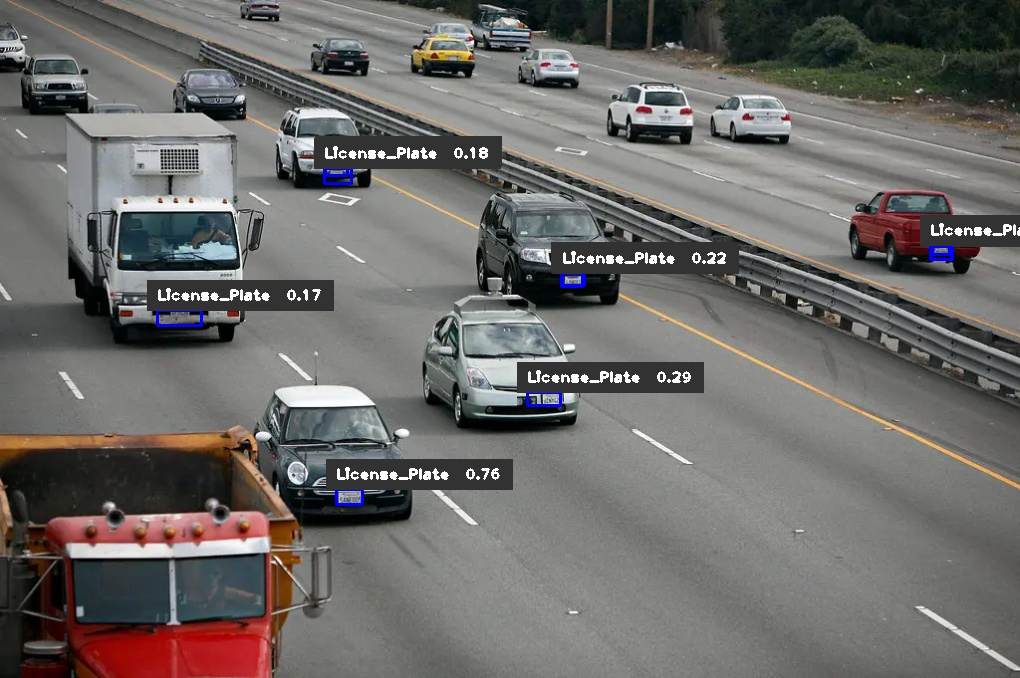

Done.


In [4]:
import numpy as np
import cv2
import os
from ultralytics import YOLO
import cvzone
import easyocr
from IPython.display import display, Image as IPImage

# ── Config ────────────────────────────────────────────────────────────────────
IMAGE_PATH      = r"/kaggle/input/datasets/ahmedhossamelrayes/ocr-trying/10google2-jumbo.png"
MODEL_PATH      = r"/kaggle/input/models/ahmedhossamelrayes/ocr/pytorch/v4/1/license-plate-ocr-v4.pt"
CONF_THRESHOLD  = 0.1
OCR_CONF_MIN    = 0.1
TARGET_WIDTH    = 1020
IMGSZ           = 640
LANG            = 'en'
PLATE_CLASS     = "License_Plate"
# ─────────────────────────────────────────────────────────────────────────────

# 1. Load YOLO model
model = YOLO(MODEL_PATH)
class_names = model.names

# 2. Initialize EasyOCR
reader = easyocr.Reader([LANG], gpu=True)

# 3. Load image
if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: '{IMAGE_PATH}'")

frame = cv2.imread(IMAGE_PATH)
if frame is None:
    raise IOError(f"Could not read image: '{IMAGE_PATH}'")

# Resize preserving aspect ratio
orig_h, orig_w = frame.shape[:2]
scale_ratio = TARGET_WIDTH / orig_w
new_h = int(orig_h * scale_ratio)
frame = cv2.resize(frame, (TARGET_WIDTH, new_h))
frame_h, frame_w = frame.shape[:2]


def preprocess_for_ocr(crop: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    if h < 200:
        scale = 200 / h
        gray = cv2.resize(gray, (int(w * scale), 200), interpolation=cv2.INTER_CUBIC)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    gray = clahe.apply(gray)

    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(gray, -1, kernel)

    return cv2.cvtColor(sharpened, cv2.COLOR_GRAY2BGR)


def perform_ocr(image_array: np.ndarray, debug_idx: int = 0) -> str:  # ← fixed
    if image_array is None or image_array.size == 0:
        return ""

    cv2.imwrite(f"crop_{debug_idx}.jpg", image_array)
    results = reader.readtext(image_array)
    print(f"Raw OCR results [crop_{debug_idx}]:", results)

    filtered = [
        text
        for (_, text, conf) in results
        if conf >= OCR_CONF_MIN
    ]
    return " ".join(filtered).strip()


def clamp_box(x1, y1, x2, y2, frame_h, frame_w):
    return (
        max(0, x1), max(0, y1),
        min(frame_w, x2), min(frame_h, y2)
    )


# YOLO inference
yolo_results = model.predict(frame, imgsz=IMGSZ, conf=CONF_THRESHOLD, verbose=False)

for idx, box in enumerate(yolo_results[0].boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, frame_h, frame_w)
    cls   = int(box.cls[0])
    conf  = float(box.conf[0])
    label = class_names[cls]

    if label != PLATE_CLASS:
        continue

    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

    crop = frame[y1:y2, x1:x2]
    plate_text = ""
    if crop.size > 0:
        # Trim 10% from each side to remove background padding
        h, w = crop.shape[:2]
        pad_y = int(h * 0.1)
        pad_x = int(w * 0.1)
        crop = crop[pad_y:h-pad_y, pad_x:w-pad_x]
        
        if crop.size > 0:
            processed_crop = preprocess_for_ocr(crop)
            plate_text = perform_ocr(processed_crop, debug_idx=idx)

        if plate_text:
            print(f"Detected Plate: {plate_text}  (confidence: {conf:.2f})")

    display_label = f"{plate_text}  {conf:.2f}" if plate_text else f"{label}  {conf:.2f}"
    text_y = y1 - 10 if y1 > 30 else y2 + 10
    cvzone.putTextRect(frame, display_label, (x1, text_y),
                       scale=1, thickness=2,
                       colorR=(50, 50, 50), colorT=(255, 255, 255))

# Save and display
output_path = "output.jpg"
cv2.imwrite(output_path, frame)
display(IPImage(output_path))
print("Done.")